## 🧭 Lesson 3: Exploratory Data Analysis (EDA) with the Tips Dataset

### 🎯 Goal

Understand how to explore data statistically and visually — to uncover structure, relationships, and anomalies before modeling.

## 🔹 1. What is EDA?

> **Exploratory Data Analysis** is the process of understanding what your data looks like, what patterns it hides, and how variables interact.

Think of it as **detective work** before building your ML model.

## 🔹 2. Math & Stats Connection

| Concept                  | Statistical Meaning          | Relevance in ML                       |
| ------------------------ | ---------------------------- | ------------------------------------- |
| Mean, Median, Mode       | Measures of central tendency | Understand data bias / skew           |
| Variance & Std Dev       | Measure spread / uncertainty | Helps normalize and scale data        |
| Skewness                 | Asymmetry of distribution    | Guides transformations (e.g., log)    |
| Covariance / Correlation | Linear relationships         | Feature selection & redundancy        |
| Outliers                 | Extreme deviations           | Affect parameter estimates and models |

### 1. Load & Inspect the Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tips = sns.load_dataset("tips")

# Inspect
print("Head", tips.head())
print("\nInfo", tips.info())
print("\nDescribe", tips.describe())
print("\n Missing value", tips.isna().sum())

Head    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Info None

Describe        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    

**What this gives you:**

* Columns:

  * `total_bill` (float)
  * `tip` (float)
  * `sex` (categorical)
  * `smoker` (categorical)
  * `day` (categorical)
  * `time` (categorical)
  * `size` (int)
* `.info()` = data types → tells you which features you’ll treat as numeric vs categorical.
* `.describe()` = mean, std, quartiles for numeric columns.
* `.isna().sum()` = missingness pattern.

Mathematically, think of this as:

* `tips` is a matrix $$( X \in \mathbb{R}^{n \times d} )$$ plus some categorical attributes.
* `.describe()` summarizes the distribution of each column as simple statistics (estimates of expected value, variance, quantiles).

### 2. Univariate EDA: One Variable at a Time

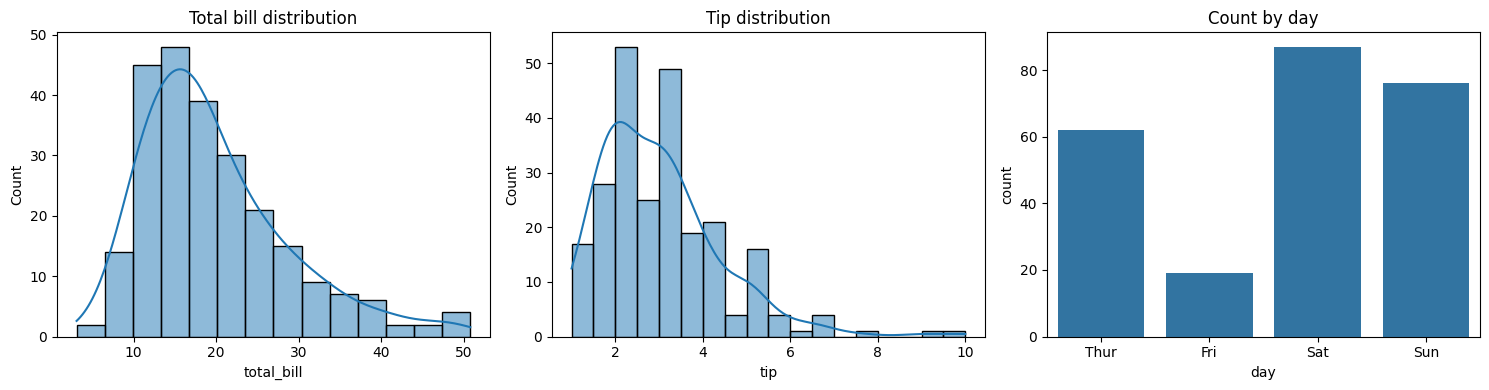

In [2]:
# Univariate EDA: One Variable at a Time
# Plot
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.histplot(tips["total_bill"], kde= True, ax= axes[0])
axes[0].set_title("Total bill distribution")

sns.histplot(tips["tip"], kde=True, ax=axes[1])
axes[1].set_title("Tip distribution")

# Cateorical data
sns.countplot(data=tips, x="day", ax=axes[2])
axes[2].set_title("Count by day")

plt.tight_layout()
plt.show()

**Interpretation ideas:**

* Are `total_bill` and `tip` skewed (right tail for large bills)?
* Which day has the most records (maybe busiest restaurant day)?

**Math tie-in:**

* Histograms approximate the **probability density** of the variable.
* KDE is a smoothed version — a continuous estimate of the underlying density ( f(x) ).

### 3. Bivariate EDA: Relationships Between Two Variables
Numeric vs Numeric: Scatter + Regression

<Figure size 500x400 with 0 Axes>

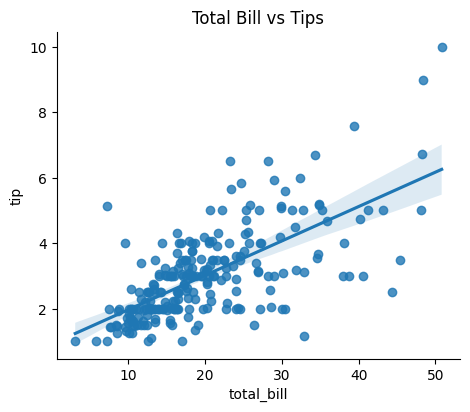

In [3]:
plt.figure(figsize=(5,4))
sns.lmplot(data=tips, x="total_bill", y="tip", height=4, aspect=1.2)
plt.title("Total Bill vs Tips")
plt.show()

**Ask:**

* Does tip grow linearly with total bill?
* Is there big spread (variance) around the line for large bills?

In [7]:
print(tips[["total_bill", "tip", "size"]].corr())

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


This is estimating pairwise linear relationships (covariance normalized by std).

#### Numeric vs Categorical: Box/Violin Plots

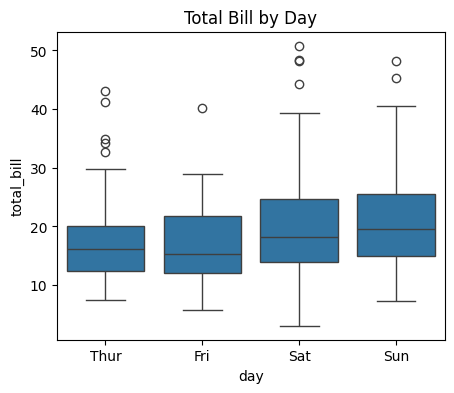

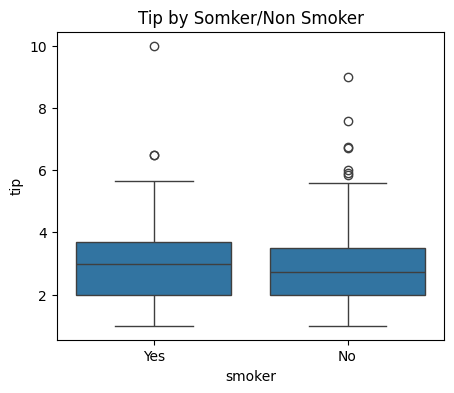

In [8]:
plt.figure(figsize=(5,4))
sns.boxplot(data=tips, x="day", y="total_bill")
plt.title("Total Bill by Day")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=tips, x='smoker', y="tip")
plt.title("Tip by Somker/Non Smoker")
plt.show()

**Interpret:**

* Which days have higher median bills?
* Any category with more variability (longer boxes/whiskers)?

**Math-tie-in:** Boxplot shows:

* median (roughly the 0.5 quantile),
* IQR (distance between 0.25 and 0.75 quantiles),
* potential outliers beyond 1.5 × IQR.

### 4. Multivariate EDA: Pairplots / Grouped Summaries

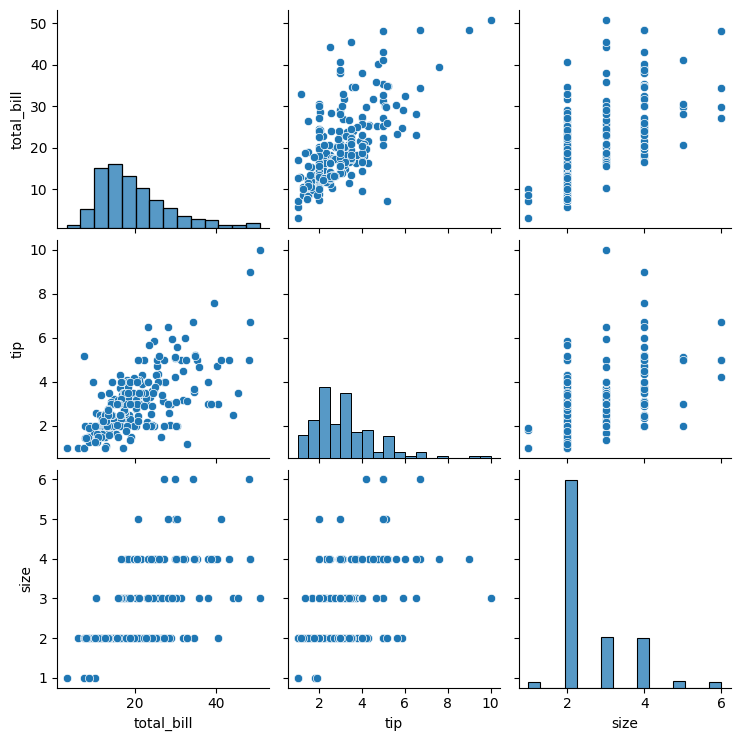

In [12]:
sns.pairplot(tips[["total_bill", "tip", "size"]])
plt.show()

This shows:

* Diagonal: distributions (hist/kde).
* Off-diagonal: scatterplots for each pair.

Geometric view: you’re seeing **projections** of your data cloud in $$(\mathbb{R}^3)$$ onto 2D planes.

**Grouped means (aggregation)**

In [14]:
group_summary = tips.groupby('day')[['total_bill', 'tip']].mean()
print(group_summary)

      total_bill       tip
day                       
Thur   17.682742  2.771452
Fri    17.151579  2.734737
Sat    20.441379  2.993103
Sun    21.410000  3.255132


C:\Users\DheerajKarki\AppData\Local\Temp\ipykernel_52660\4055506662.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_summary = tips.groupby('day')[['total_bill', 'tip']].mean()


This is:

$$

\text{mean tip on day } d = \frac{1}{n_d} \sum_{i: day_i = d} tip_i

$$

This is literally just computing conditional expectations like $$( \mathbb{E}[\text{tip} \mid \text{day}] )$$

## 🧠 Mini EDA Exercise

Let’s keep using the `tips` dataset.

### Task

1. **Inspect**

   * Print `.head()`, `.info()`, `.describe()` and `.isna().sum()` for `tips`.

2. **Univariate EDA**

   * Plot:

     * histogram + KDE for `tip`,
     * histogram + KDE for `total_bill`.

3. **Bivariate EDA**

   * Compute the correlation between `total_bill`, `tip`, and `size`.
   * Make a scatter plot or `regplot` of `total_bill` vs `tip`.
   * Make a boxplot of `tip` by `day`.

4. **Interpretation (just a few sentences)**

   * Is `tip` more strongly associated with `total_bill` or with `size`?
   * Do any days seem to have notably higher or lower tips (median), based on the boxplot?

You can answer with:

* Your **code**, and
* 2–4 bullet points of **interpretation**.

Head    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None

Describe        total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    

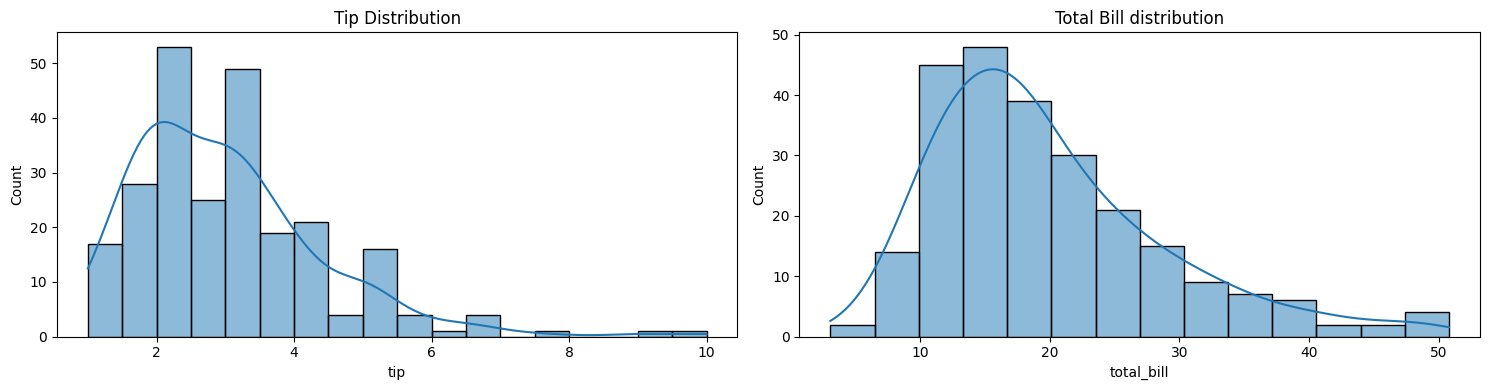

            total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


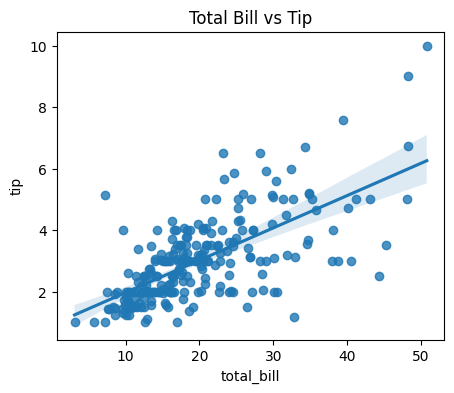

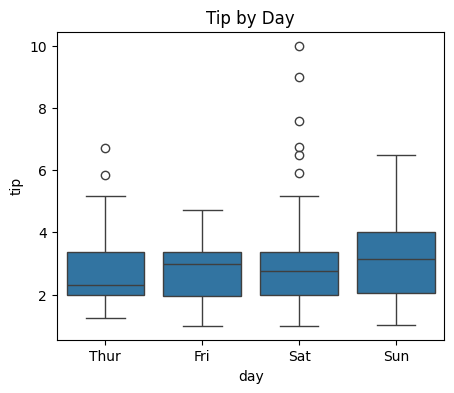

In [18]:
# 1. Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("tips")

# 2. Inspect
print("Head", df.head())
print("\nInfo")
print(df.info())
print("\nDescribe", df.describe())
print("\nMissing Values", df.isna().sum())

# 3. Univariate EDA
fig, axes = plt.subplots(1,2, figsize=(15,4))

sns.histplot(data=df["tip"], kde=True, ax=axes[0])
axes[0].set_title("Tip Distribution")

sns.histplot(data=df["total_bill"], kde=True, ax=axes[1])
axes[1].set_title("Total Bill distribution")

plt.tight_layout()
plt.show()

# 4. Bivariate EDA
print(df[["total_bill", "tip", "size"]].corr())

plt.figure(figsize=(5,4))
sns.regplot(data=df, x="total_bill", y="tip")
plt.title("Total Bill vs Tip")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(data=df, x="day", y="tip")
plt.title("Tip by Day")
plt.show()

# 5. Interpretations 
#Is tip more strongly associated with total_bill or with size?
#Interpretation: looking at the correlation value of tip with total_bill and size is 0.675734 and 0.489299 respectively. 
#So total_bill is more strongly assocaited with tip. Although statistically both are moderately strong.

#Do any days seem to have notably higher or lower tips (median), based on the boxplot?
#Interpretation: It looks like on Sunday the median is notably higher while on Thursday it is notably lower
